<a href="https://colab.research.google.com/github/AileenLavelle/PBC_Object_Detection/blob/main/Recreating_Roboflow_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trying to recreate the pre-processing I did in Roboflow

## Step 1: Install Dependencies

In [2]:
!pip install -q ultralytics opencv-python-headless
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00
Done!


## Step 2: Import Libraries

In [3]:
import os
import json
import shutil
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Check for Colab
try:
    from google.colab import files, drive
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Running in Google Colab


## Step 3: Configure Paths

**IMPORTANT:** Update these paths to match your setup!

In [4]:
#setting paths
COCO_JSON = "/content/_annotations.coco.json"
IMAGES_DIR = "/content/Jupiter_Inlet"
OUTPUT_DIR = "/content/Jupiter_Inlet/jupiter_inlet_yolo"

# Roboflow preprocessing settings
APPLY_PREPROCESSING = True  # Set to False if images are already preprocessed
CROP_HORIZONTAL = (0.33, 1.0)   # 33-100% horizontal
CROP_VERTICAL = (0.28, 0.49)    # 28-49% vertical
RESIZE_TO = (2048, 800)         # Width x Height

print(f"COCO JSON: {COCO_JSON}")
print(f"Images dir: {IMAGES_DIR}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Apply preprocessing: {APPLY_PREPROCESSING}")

COCO JSON: /content/_annotations.coco.json
Images dir: /content/Jupiter_Inlet
Output dir: /content/Jupiter_Inlet/jupiter_inlet_yolo
Apply preprocessing: True


## Step 4: Load COCO Annotations

In [5]:
def load_coco_json(json_path):
    """Safely load COCO JSON"""
    print(f"Loading: {json_path}")

    for encoding in ['utf-8-sig', 'utf-8', 'latin-1']:
        try:
            with open(json_path, 'r', encoding=encoding) as f:
                content = f.read().strip()
            if content.startswith('\ufeff'):
                content = content[1:]
            data = json.loads(content)
            print(f"Loaded successfully ({encoding})")
            return data
        except Exception as e:
            continue
    raise ValueError("Could not parse JSON")

coco_data = load_coco_json(COCO_JSON)

print(f"\n{'='*50}")
print(f"Dataset Summary:")
print(f"{'='*50}")
print(f"  Images: {len(coco_data['images'])}")
print(f"  Annotations: {len(coco_data['annotations'])}")
print(f"  Categories: {coco_data['categories']}")

if coco_data['images']:
    img = coco_data['images'][0]
    print(f"  Original image size: {img['width']} x {img['height']}")

    if img['width'] > 2048 or img['height'] > 800:
        print(f"\ Images are RAW (not preprocessed by Roboflow)")
        print(f"   Will apply preprocessing: crop + resize to {RESIZE_TO}")

Loading: /content/_annotations.coco.json
Loaded successfully (utf-8-sig)

Dataset Summary:
  Images: 366
  Annotations: 1199
  Categories: [{'id': 0, 'name': 'Boat', 'supercategory': 'none'}, {'id': 1, 'name': 'Boat', 'supercategory': 'Boat'}]
  Original image size: 4352 x 3264

⚠️  Images are RAW (not preprocessed by Roboflow)
   Will apply preprocessing: crop + resize to (2048, 800)


## Step 5: Find Source Images

This cell finds where your images are located (excluding output directories).

In [6]:
def find_all_source_images(base_dir, exclude_patterns=['yolo', 'output', 'labels']):
    """
    Find all source images, excluding output directories.
    Returns a dict mapping filename -> full path
    """
    base_path = Path(base_dir)
    all_images = {}

    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        for f in base_path.rglob(ext):
            # Skip output/yolo directories
            path_str = str(f).lower()
            if any(pattern in path_str for pattern in exclude_patterns):
                continue
            all_images[f.name] = f

    return all_images

# Find images
source_images = find_all_source_images(IMAGES_DIR)
print(f"Found {len(source_images)} source images")

# Show some examples
if source_images:
    examples = list(source_images.items())[:3]
    print("\nExample images found:")
    for name, path in examples:
        print(f"  {name} -> {path}")

Found 366 source images

Example images found:
  s290939t_jpg.rf.2962bf5aef161adc28ac528600688236.jpg -> /content/Jupiter_Inlet/s290939t_jpg.rf.2962bf5aef161adc28ac528600688236.jpg
  a101725b_jpg.rf.aa96aa14c5c534c72ce09782459c34c4.jpg -> /content/Jupiter_Inlet/a101725b_jpg.rf.aa96aa14c5c534c72ce09782459c34c4.jpg
  a011225e_jpg.rf.16674db34946941976a246c469ad2988.jpg -> /content/Jupiter_Inlet/a011225e_jpg.rf.16674db34946941976a246c469ad2988.jpg


## Step 6: Preprocessing Function

This applies the same preprocessing I used in Roboflow:
- Static Crop: 33-100% Horizontal, 28-49% Vertical
- Resize: Stretch to 2048x800

In [7]:
def apply_roboflow_preprocessing(image, crop_h=(0.33, 1.0), crop_v=(0.28, 0.49), resize_to=(2048, 800)):
    """
    Apply Roboflow's preprocessing to an image.

    Args:
        image: numpy array (BGR)
        crop_h: (start, end) horizontal crop percentages
        crop_v: (start, end) vertical crop percentages
        resize_to: (width, height) final size

    Returns:
        Preprocessed image, crop_info dict for adjusting bboxes
    """
    h, w = image.shape[:2]

    # Calculate crop coordinates
    x1 = int(w * crop_h[0])
    x2 = int(w * crop_h[1])
    y1 = int(h * crop_v[0])
    y2 = int(h * crop_v[1])

    # Crop
    cropped = image[y1:y2, x1:x2]
    crop_h_actual, crop_w_actual = cropped.shape[:2]

    # Resize
    resized = cv2.resize(cropped, resize_to, interpolation=cv2.INTER_LINEAR)

    # Info needed to transform bounding boxes
    crop_info = {
        'orig_w': w,
        'orig_h': h,
        'crop_x1': x1,
        'crop_y1': y1,
        'crop_w': crop_w_actual,
        'crop_h': crop_h_actual,
        'final_w': resize_to[0],
        'final_h': resize_to[1],
    }

    return resized, crop_info


def transform_bbox(bbox, crop_info):
    """
    Transform a COCO bbox from original image coords to preprocessed image coords.

    Args:
        bbox: [x_min, y_min, width, height] in original image coords
        crop_info: dict from apply_roboflow_preprocessing

    Returns:
        Transformed bbox or None if bbox is outside crop region
    """
    x_min, y_min, bw, bh = bbox
    x_max = x_min + bw
    y_max = y_min + bh

    # Crop coordinates
    cx1, cy1 = crop_info['crop_x1'], crop_info['crop_y1']
    cx2 = cx1 + crop_info['crop_w']
    cy2 = cy1 + crop_info['crop_h']

    # Check if bbox is completely outside crop region
    if x_max <= cx1 or x_min >= cx2 or y_max <= cy1 or y_min >= cy2:
        return None  # bbox outside crop

    # Clip bbox to crop region
    x_min = max(x_min, cx1)
    y_min = max(y_min, cy1)
    x_max = min(x_max, cx2)
    y_max = min(y_max, cy2)

    # Translate to crop coordinates
    x_min -= cx1
    y_min -= cy1
    x_max -= cx1
    y_max -= cy1

    # Scale to final size
    scale_x = crop_info['final_w'] / crop_info['crop_w']
    scale_y = crop_info['final_h'] / crop_info['crop_h']

    x_min *= scale_x
    y_min *= scale_y
    x_max *= scale_x
    y_max *= scale_y

    # Convert back to [x, y, w, h]
    new_bbox = [x_min, y_min, x_max - x_min, y_max - y_min]

    # Skip tiny boxes (likely cut off by crop)
    if new_bbox[2] < 2 or new_bbox[3] < 2:
        return None

    return new_bbox

print("Preprocessing functions defined!")

Preprocessing functions defined!


## Step 7: Convert COCO to YOLO (with preprocessing)

In [8]:
def coco_to_yolo_with_preprocessing(
    coco_data,
    source_images,
    output_dir,
    apply_preprocessing=True,
    crop_h=(0.33, 1.0),
    crop_v=(0.28, 0.49),
    resize_to=(2048, 800),
    train_split=0.8
):
    """
    Convert COCO to YOLO format with optional Roboflow preprocessing.
    """
    output_path = Path(output_dir)

    # Clean output directory
    if output_path.exists():
        shutil.rmtree(output_path)

    # Create directories
    for split in ['train', 'val']:
        (output_path / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_path / 'labels' / split).mkdir(parents=True, exist_ok=True)

    # Build mappings
    image_map = {img['id']: img for img in coco_data['images']}

    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    # Train/val split
    image_ids = list(image_map.keys())
    split_idx = int(len(image_ids) * train_split)
    train_ids = set(image_ids[:split_idx])

    print(f"Train: {len(train_ids)}, Val: {len(image_ids) - len(train_ids)}")
    print(f"Preprocessing: {apply_preprocessing}")

    processed = 0
    missing = 0
    skipped_anns = 0

    for img_id, img_info in image_map.items():
        orig_width = img_info['width']
        orig_height = img_info['height']
        img_filename = img_info['file_name']
        basename = Path(img_filename).name

        # Find source image
        src_path = None
        if basename in source_images:
            src_path = source_images[basename]
        elif img_filename in source_images:
            src_path = source_images[img_filename]

        if src_path is None:
            missing += 1
            if missing <= 5:
                print(f"  Missing: {img_filename}")
            continue

        split = 'train' if img_id in train_ids else 'val'

        # Process image
        image = cv2.imread(str(src_path))
        if image is None:
            missing += 1
            continue

        if apply_preprocessing:
            # Apply Roboflow preprocessing
            image, crop_info = apply_roboflow_preprocessing(
                image, crop_h, crop_v, resize_to
            )
            final_w, final_h = resize_to
        else:
            crop_info = None
            final_h, final_w = image.shape[:2]

        # Save image
        dst_img = output_path / 'images' / split / basename
        cv2.imwrite(str(dst_img), image)

        # Convert annotations
        yolo_lines = []
        if img_id in annotations_by_image:
            for ann in annotations_by_image[img_id]:
                bbox = ann['bbox']  # [x_min, y_min, w, h]

                if apply_preprocessing and crop_info:
                    # Transform bbox to preprocessed coordinates
                    bbox = transform_bbox(bbox, crop_info)
                    if bbox is None:
                        skipped_anns += 1
                        continue

                x_min, y_min, bw, bh = bbox

                # Convert to YOLO format (normalized center coords)
                x_center = (x_min + bw / 2) / final_w
                y_center = (y_min + bh / 2) / final_h
                w_norm = bw / final_w
                h_norm = bh / final_h

                # Clamp to [0, 1]
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                w_norm = max(0, min(1, w_norm))
                h_norm = max(0, min(1, h_norm))

                yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

        # Save labels
        label_path = output_path / 'labels' / split / (Path(basename).stem + '.txt')
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))

        processed += 1

        if processed % 50 == 0:
            print(f"  Processed {processed} images...")

    print(f"\n{'='*50}")
    print(f"Conversion complete!")
    print(f"  Processed: {processed}")
    print(f"  Missing: {missing}")
    if apply_preprocessing:
        print(f"  Annotations outside crop: {skipped_anns}")
    print(f"{'='*50}")

    # Create data.yaml
    data_yaml = f"""path: {output_path.absolute()}
train: images/train
val: images/val
nc: 1
names:
  0: Boat
"""

    yaml_path = output_path / 'data.yaml'
    with open(yaml_path, 'w') as f:
        f.write(data_yaml)

    print(f"\nCreated: {yaml_path}")
    return str(yaml_path)


# Run conversion
data_yaml_path = coco_to_yolo_with_preprocessing(
    coco_data,
    source_images,
    OUTPUT_DIR,
    apply_preprocessing=APPLY_PREPROCESSING,
    crop_h=CROP_HORIZONTAL,
    crop_v=CROP_VERTICAL,
    resize_to=RESIZE_TO,
)

Train: 292, Val: 74
Preprocessing: True
  Processed 50 images...
  Processed 100 images...
  Processed 150 images...
  Processed 200 images...
  Processed 250 images...
  Processed 300 images...
  Processed 350 images...

Conversion complete!
  Processed: 366
  Missing: 0
  Annotations outside crop: 150

Created: /content/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml


## Step 8: Verify Conversion

In [9]:
# Count files
train_imgs = list(Path(OUTPUT_DIR).glob('images/train/*'))
val_imgs = list(Path(OUTPUT_DIR).glob('images/val/*'))
train_labels = list(Path(OUTPUT_DIR).glob('labels/train/*'))
val_labels = list(Path(OUTPUT_DIR).glob('labels/val/*'))

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")
print(f"Train labels: {len(train_labels)}")
print(f"Val labels: {len(val_labels)}")

# Check image dimensions
if train_imgs:
    sample_img = cv2.imread(str(train_imgs[0]))
    print(f"\nSample image size: {sample_img.shape[1]} x {sample_img.shape[0]}")
    print(f"Expected size: {RESIZE_TO[0]} x {RESIZE_TO[1]}")

Train images: 292
Val images: 74
Train labels: 292
Val labels: 74

Sample image size: 2048 x 800
Expected size: 2048 x 800


## Step 9: Visualize a Sample (with bounding boxes)

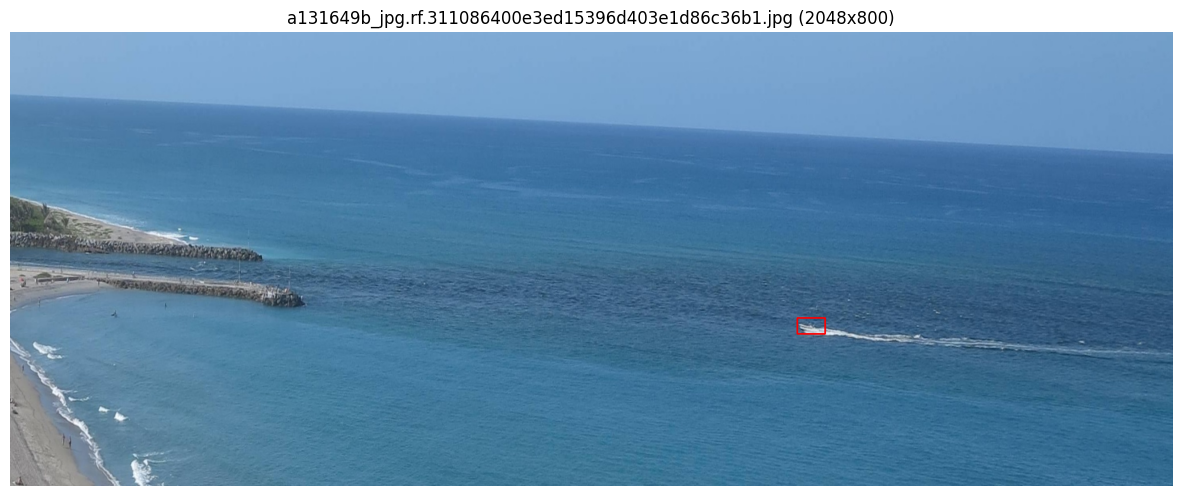

In [10]:
def visualize_sample(output_dir, split='train'):
    """Visualize a random sample with bounding boxes"""
    output_path = Path(output_dir)

    # Get a sample
    images = list((output_path / 'images' / split).glob('*'))
    if not images:
        print("No images found!")
        return

    import random
    sample_img_path = random.choice(images)
    label_path = output_path / 'labels' / split / (sample_img_path.stem + '.txt')

    # Load image
    img = cv2.imread(str(sample_img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Load and draw labels
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, bw, bh = map(float, parts)
                    # Convert to pixel coords
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(15, 6))
    plt.imshow(img)
    plt.title(f"{sample_img_path.name} ({w}x{h})")
    plt.axis('off')
    plt.show()

visualize_sample(OUTPUT_DIR, 'train')

## Step 10: Train YOLO11

In [ ]:
# Load model
model = YOLO('yolo11s.pt')

# Train
results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=2048,           # Match preprocessed width
    batch=4,              # Reduce if OOM
    rect=True,            # For non-square images
    device=0,

    # Small object optimizations
    mosaic=0.5,
    scale=0.2,

    # Augmentations
    fliplr=0.5,
    flipud=0.0,

    # Training
    patience=50,
    save=True,
    plots=True,

    project='jupiter_inlet',
    name='train',
)

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=2048, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## Step 11: Validate

In [ ]:
best_weights = 'jupiter_inlet/train/weights/best.pt'
model = YOLO(best_weights)

metrics = model.val(
    data=data_yaml_path,
    imgsz=2048,
    rect=True,
    conf=0.001,
    iou=0.5,
)

print("\n" + "=" * 50)
print("YOUR RESULTS:")
print(f"  mAP@50:    {metrics.box.map50:.1%}")
print(f"  Precision: {metrics.box.mp:.1%}")
print(f"  Recall:    {metrics.box.mr:.1%}")
print("=" * 50)
print("ROBOFLOW TARGET:")
print("  mAP@50:    83.8%")
print("  Precision: 86.0%")
print("  Recall:    76.0%")
print("=" * 50)

## Step 12: Test Inference

In [ ]:
# Get a test image
test_images = list(Path(OUTPUT_DIR).glob('images/val/*.jpg'))

if test_images:
    test_img = str(test_images[0])
    print(f"Testing: {test_img}")

    results = model.predict(
        source=test_img,
        imgsz=2048,
        conf=0.25,
        save=True,
    )

    print(f"Detected {len(results[0].boxes)} boats")

    result_img = results[0].plot()
    plt.figure(figsize=(15, 6))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## Step 13: Download Model

In [ ]:
if IN_COLAB:
    from google.colab import files
    weights_path = 'jupiter_inlet/train/weights/best.pt'
    if os.path.exists(weights_path):
        files.download(weights_path)
    else:
        print(f"Weights not found at {weights_path}")